In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical

from PIL import Image
from tensorflow.keras.callbacks import EarlyStopping


In [35]:
# Define path to dataset
data_dir = 'yoga_dataset'
img_height, img_width = 150, 150
batch_size = 8

# Use ImageDataGenerator to load images
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
def clean_invalid_images(root_dir):
    supported_formats = ('.jpg', '.jpeg', '.png')
    removed = 0
    for subdir, _, files in os.walk(root_dir):
        for file in files:
            file_path = os.path.join(subdir, file)
            if not file.lower().endswith(supported_formats):
                os.remove(file_path)
                removed += 1
                continue
            try:
                img = Image.open(file_path)
                img.verify()  # Check if the image can be opened
            except:
                os.remove(file_path)
                removed += 1
    print(f"Removed {removed} invalid or unsupported images.")

clean_invalid_images("yoga_dataset")

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Removed 0 invalid or unsupported images.
Found 440 images belonging to 7 classes.
Found 107 images belonging to 7 classes.


In [44]:
#Design the model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.4), 
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 34, 34, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,791 (1.75 MB)

 Trainable params: 458,791 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
     callbacks=[early_stop]
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - accuracy: 0.2148 - loss: 1.9236 - val_accuracy: 0.3178 - val_loss: 1.7537
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.3813 - loss: 1.6849 - val_accuracy: 0.5140 - val_loss: 1.5011
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.5498 - loss: 1.3524 - val_accuracy: 0.5047 - val_loss: 1.3878
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.6722 - loss: 0.9387 - val_accuracy: 0.5981 - val_loss: 1.3185
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.7435 - loss: 0.8070 - val_accuracy: 0.5794 - val_loss: 1.5079
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.8740 - loss: 0.3859 - val_accuracy: 0.5607 - val_loss: 1.6014
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - accuracy: 0.9418 - loss: 0.2554 - val_accuracy: 0.6168 - val_loss: 1.9924


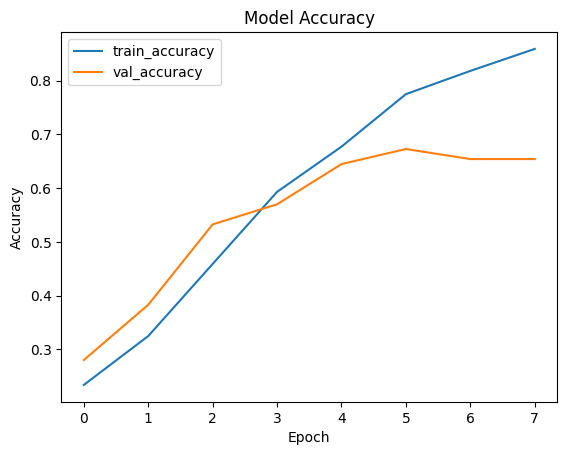

In [38]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()